<p style="text-align:center;text-justify:inter-word;"><img src="../LabDataScience.png" alt="Seja bem vindo ao meu laboratório de ciência de dados!" width="800" height="600"></p>

# Redução de Churn de Companhia Telefônica # 

### 🧭 Metodologia CRISP-DM – Estrutura de Acompanhamento ###

Vou seguir as **6 fases do CRISP-DM**, sempre analisando cada uma sob três perspectivas:

- **O que o negócio quer**  
- **O que o cientista de dados faz**  
- **Resultado concreto**

## 📓 Fase 01 - Business Understanding ##

<p style="text-align:justify;text-justify:inter-word;">Reduzir significativamente a perda de clientes na empresa de telecom, por meio de identificação de  sinais precoces de insatisfação e risco de cancelamento.
</p>

## 📓 Fase 02 - Data Understanding (Visão Geral dos Dados) ##

<p style="text-align:justify;text-justify:inter-word;">Visão geral dos dados. Histórico completo de uso de serviços, registros de reclamações e atendimentos, perfil demográfico, dados de faturamento e interações com suporte técnico.</p>


In [1]:
##carregando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

#faz com que gráficos do Matplotlib apareçam diretamente dentro da célula de saída do notebook
%matplotlib inline

<h3>CARREGANO O DATASET</h3>

In [26]:
## importando dados do dataset para um dataframe 
df = pd.read_csv("telecom_churn_synthetic.csv")

## Formato do dataframe
print("Forma do dataframe (linhas x colunas):")
df.shape


Forma do dataframe (linhas x colunas):


(6000, 27)

In [3]:
## visualizando o cabeçalho as colunas (nomes dos atributos)
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps',
       'late_payments_last_6m', 'promo_active', 'discount_pct', 'churn'],
      dtype='object')

<h3>📊 Dicionário de Dados – Dataset de Clientes (Churn)</h3>

| # | Categoria | Campo (coluna) | Descrição (PT-BR) |
|---|-----------|----------------|-------------------|
| 1 | Identificação do cliente | `customer_id` | Identificador único do cliente |
| 2 | Perfil demográfico | `gender` | Gênero do cliente |
| 3 | Perfil demográfico | `senior_citizen` | Indica se o cliente é idoso (1 = sim, 0 = não) |
| 4 | Perfil demográfico | `partner` | Indica se o cliente possui parceiro(a) |
| 5 | Perfil demográfico | `dependents` | Indica se o cliente possui dependentes |
| 6 | Relacionamento com a empresa | `tenure_months` | Tempo de relacionamento do cliente com a empresa, em meses |
| 7 | Serviços contratados | `phone_service` | Indica se o cliente possui serviço de telefonia |
| 8 | Serviços contratados | `multiple_lines` | Indica se o cliente possui múltiplas linhas telefônicas |
| 9 | Serviços contratados | `internet_service` | Tipo de serviço de internet contratado (ex.: fibra, DSL, nenhum) |
|10 | Serviços contratados | `online_security` | Indica se o cliente possui serviço de segurança online |
|11 | Serviços contratados | `online_backup` | Indica se o cliente possui serviço de backup online |
|12 | Serviços contratados | `device_protection` | Indica se o cliente possui serviço de proteção de dispositivos |
|13 | Serviços contratados | `tech_support` | Indica se o cliente possui serviço de suporte técnico |
|14 | Serviços contratados | `streaming_tv` | Indica se o cliente possui serviço de streaming de TV |
|15 | Serviços contratados | `streaming_movies` | Indica se o cliente possui serviço de streaming de filmes |
|16 | Contrato e cobrança | `contract` | Tipo de contrato do cliente (mensal, anual ou bienal) |
|17 | Contrato e cobrança | `paperless_billing` | Indica se o cliente utiliza fatura digital (sem papel) |
|18 | Contrato e cobrança | `payment_method` | Forma de pagamento utilizada pelo cliente |
|19 | Contrato e cobrança | `monthly_charges` | Valor mensal cobrado do cliente |
|20 | Contrato e cobrança | `total_charges` | Valor total pago pelo cliente ao longo do relacionamento |
|21 | Qualidade do serviço | `complaints_last_3m` | Número de reclamações nos últimos 3 meses |
|22 | Qualidade do serviço | `outages_last_3m` | Número de falhas ou interrupções nos últimos 3 meses |
|23 | Qualidade do serviço | `avg_download_mbps` | Velocidade média de download do cliente (Mbps) |
|24 | Comportamento financeiro | `late_payments_last_6m` | Número de pagamentos em atraso nos últimos 6 meses |
|25 | Promoções | `promo_active` | Indica se o cliente possui promoção ativa |
|26 | Promoções | `discount_pct` | Percentual de desconto aplicado ao cliente |
|27 | Variável alvo | `churn` | Indica se o cliente cancelou o serviço (1 = cancelou, 0 = permaneceu) |

> **Observação didática:**  
> Este dataset permite construir uma **visão 360° do cliente**, integrando perfil, contrato, uso do serviço, experiência e comportamento financeiro, sendo ideal para estudos de **Data Mining e previsão de churn**.


In [4]:
## visualizando os dados do dataset
## pode ser apenas df (o nome do dataframe) ou df.head()
df

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,Mailed check,111.37,5814.37,0,1,209.6,0,Yes,24.0,0
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,...,Electronic check,33.94,1674.85,0,3,41.2,2,No,0.0,0
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,Bank transfer (automatic),101.19,6167.86,2,0,173.4,0,No,0.0,0
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,...,Electronic check,77.53,444.59,1,0,34.8,2,No,0.0,0
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,Mailed check,67.96,1541.46,0,1,222.3,0,No,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,C0005996,Female,0,No,No,11,Yes,No,No,No internet service,...,Credit card (automatic),37.33,414.38,0,0,0.0,0,Yes,12.5,0
5996,C0005997,Male,0,Yes,No,15,Yes,No,No,No internet service,...,Bank transfer (automatic),18.00,250.89,1,2,0.0,0,No,0.0,0
5997,C0005998,Male,0,Yes,Yes,6,Yes,No,Fiber optic,Yes,...,Mailed check,77.56,528.06,0,0,104.2,1,No,0.0,0
5998,C0005999,Male,0,Yes,No,11,Yes,No,DSL,No,...,Bank transfer (automatic),49.86,521.75,0,0,17.1,0,No,0.0,0


In [5]:
# Analisa apenas colunas numéricas (int, float)
# Colunas categóricas ficam de fora (gender, contract, etc.)

# Mostra:
## count:
### Quantidade de valores NÃO nulos (válidos) na coluna.
### Se for menor que o total de registros, indica presença de dados faltantes (missing).

## mean:
# Média aritmética dos valores da coluna.
# Representa o valor médio observado e pode ser sensível a outliers.

## std:
# Desvio padrão dos valores.
# Mede o quanto os dados variam em relação à média.
# Quanto maior, maior a dispersão dos dados.

## min:
# Menor valor observado na coluna.
# Ajuda a identificar limites inferiores e possíveis valores anômalos.

## 25% (primeiro quartil - Q1):
# Valor abaixo do qual estão 25% dos dados.
# Indica o limite inferior da distribuição central.

## 50% (mediana - Q2):
# Valor central da distribuição.
# Metade dos dados está abaixo e metade acima.
# Mais robusta que a média em presença de outliers.

## 75% (terceiro quartil - Q3):
# Valor abaixo do qual estão 75% dos dados.
# Indica o limite superior da distribuição central.

## max:
# Maior valor observado na coluna.
# Ajuda a identificar limites superiores e possíveis outliers.


df.describe()

,senior_citizen,tenure_months,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,discount_pct,churn
count,6000.000000,6000.000000,6000.000000,5926.000000,6000.000000,6000.000000,5954.000000,6000.000000,6000.000000,6000.000000
mean,0.156500,28.685000,69.063478,1977.805548,0.408833,0.470167,85.650420,0.389500,3.272383,0.140500
std,0.363359,22.306495,28.521629,1860.606539,0.654288,0.701089,77.047655,0.659188,6.152472,0.347534
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,8.000000,50.870000,468.655000,0.000000,0.000000,21.800000,0.000000,0.000000,0.000000
50%,0.000000,24.000000,72.640000,1303.255000,0.000000,0.000000,48.400000,0.000000,0.000000,0.000000
75%,0.000000,47.250000,89.690000,3166.367500,1.000000,1.000000,154.300000,1.000000,3.300000,0.000000
max,1.000000,72.000000,140.000000,9809.360000,5.000000,5.000000,330.000000,5.000000,35.000000,1.000000


In [6]:
# df.describe(include="all").T
#
# df.describe(include="all"):
# Gera um resumo estatístico de TODAS as colunas do DataFrame,
# incluindo variáveis numéricas, categóricas e binárias.
# Para cada tipo de dado, o pandas aplica estatísticas apropriadas:
# - Numéricas: count, mean, std, min, quartis e max
# - Categóricas: count, unique, top (valor mais frequente) e freq
#
# include="all":
# Força a inclusão de todas as colunas, independentemente do tipo de dado.
# Sem esse parâmetro, apenas variáveis numéricas seriam analisadas.
#
# .T (transpose):
# Transpõe o resultado, trocando linhas por colunas.
# Isso faz com que cada linha represente uma variável
# e cada coluna represente uma estatística,
# facilitando a leitura e a análise exploratória dos dados (EDA).

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,6000,6000,C0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,6000,2,Male,3012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,6000.0,NaN,NaN,NaN,0.1565,0.363359,0.0,0.0,0.0,0.0,1.0
partner,6000,2,No,3317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,6000,2,No,4156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,6000.0,NaN,NaN,NaN,28.685,22.306495,0.0,8.0,24.0,47.25,72.0
phone_service,6000,2,Yes,5394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiple_lines,6000,3,No,2947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,6000,3,Fiber optic,2757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,6000,3,No,3261,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Retorna a quantidade de idosos (pergunta do aluno)
df['senior_citizen'].value_counts()

senior_citizen
0    5061
1     939
Name: count, dtype: int64

### Metadados ###

In [8]:
# Mostra os metadados do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            6000 non-null   object 
 1   gender                 6000 non-null   object 
 2   senior_citizen         6000 non-null   int64  
 3   partner                6000 non-null   object 
 4   dependents             6000 non-null   object 
 5   tenure_months          6000 non-null   int64  
 6   phone_service          6000 non-null   object 
 7   multiple_lines         6000 non-null   object 
 8   internet_service       6000 non-null   object 
 9   online_security        6000 non-null   object 
 10  online_backup          6000 non-null   object 
 11  device_protection      6000 non-null   object 
 12  tech_support           6000 non-null   object 
 13  streaming_tv           6000 non-null   object 
 14  streaming_movies       6000 non-null   object 
 15  cont

# Taxa de Churn (base rate) #

In [9]:
# Conta quantas ocorrências absolutas existem de cada valor na coluna churn
df["churn"].value_counts()

churn
0    5157
1     843
Name: count, dtype: int64

In [10]:
# Conta a proporção de cada valor em relação ao total. Retorna frequência relativa (percentual).
df["churn"].value_counts(normalize=True)

churn
0    0.8595
1    0.1405
Name: proportion, dtype: float64

#### 👉 Interpretação: ####

- 85,95% dos clientes não churnaram

- 14,05% churnaram

#### Se quiser em percentual explícito direto: ####

In [11]:
# Percentual explícito
df["churn"].value_counts(normalize=True) * 100

churn
0    85.95
1    14.05
Name: proportion, dtype: float64

## 📌 Observações ##

#### Variáveis categóricas dominam → encoding será crítico: ####

- tenure_months, monthly_charges e complaints_last_3m já “cheiram” a churn
- Target binário e desbalanceado (vida real, não Kaggle)

# Churn por Tipo de Contrato #

In [12]:
# Cria uma tabela cruzada mostrando a proporção de churn para cada tipo de contrato
pd.crosstab(df["contract"], df["churn"], normalize="index")

churn,0,1
contract,,
Month-to-month,0.804264,0.195736
One year,0.927720,0.072280
Two year,0.933646,0.066354


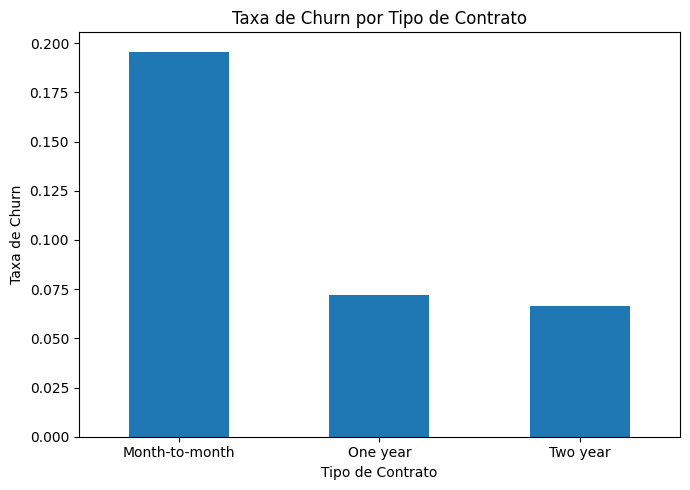

In [13]:
# taxa média de churn por tempo de contrato
churn_by_contract = (
    df.groupby("contract")["churn"]
    .mean()
    .sort_values(ascending=False)
) 

# plot (Gráfico)
plt.figure(figsize=(7,5))
churn_by_contract.plot(kind="bar")

plt.title("Taxa de Churn por Tipo de Contrato")
plt.ylabel("Taxa de Churn")
plt.xlabel("Tipo de Contrato")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()


### 📌 Interpretação: ### 
🔹 **Contrato Month-to-month (mensal)**

**Month-to-month: 	0.804264	0.195736**

Significa que:
- 80,43% dos clientes permanecem
- 19,57% dos clientes cancelam

🔹 **Contrato One year (anual)**

**One year: 0.927720 0.072280**

Significa que:
- 92,77% permanecem
- 7,23% cancelam

🔹 **Contrato Two year (bienal)**

**Two year: 0.933646 0.066354**

Significa que:
- 93,36% permanecem
- 6,64% cancelam

### 🧠 Análises ###

- Contrato mensal tem maior risco de churn.
- Contrato anual reduz o churn em mais de 60% em relação ao mensal.
- Contrato bienal apresenta menor churn, mas ganho marginal em relação ao anual é pequeno.

### 💡 Insight de negócio (o que importa de verdade) ###

- Contrato mensal é o principal fator de risco

- Migrar cliente de mensal → anual já reduz fortemente o churn

- Bienal melhora pouco em relação ao anual

- Pode não justificar incentivos agressivos

### 👉 Estratégia típica: ###

- Quanto maior o prazo do contrato, menor a taxa de churn — com risco concentrado nos contratos mensais.

- Foco em converter mensal → anual

- Ofertas direcionadas a clientes mensais com sinais de risco

### 🔄 Conexão com Data Mining ###

**Essa variável (contract) é:**

- fortemente preditiva

- excelente candidata a:

- feature principal

- regras de negócio

- segmentação de campanhas

### Próximo passo natural: ###

- transformar isso em feature ordinal

- cruzar contrato × tenure

- ver contrato × reclamações

### O que é uma feature ordinal? ###

É uma variável categórica com ordem natural entre as categorias.

Exemplos clássicos:

- baixo < médio < alto

- ruim < regular < bom < ótimo

- curto < médio < longo

No nosso caso: 

*Month-to-month*  <  *One year*  <  *Two year*

👉 Existe ordem lógica e de risco.

### Por que isso importa? ###

Porque o modelo precisa saber que existe hierarquia.

Se você tratar como:

- one-hot → o modelo perde a noção de ordem

- string → o modelo não entende nada

### Transformar contract em feature ordinal ###

Significa converter categorias em números que preservam a ordem.

Exemplo simples e correto:

In [14]:
contract_map = {
    "Month-to-month": 1,
    "One year": 2,
    "Two year": 3
}

df["contract_ordinal"] = df["contract"].map(contract_map)


In [15]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure_months', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'complaints_last_3m', 'outages_last_3m', 'avg_download_mbps',
       'late_payments_last_6m', 'promo_active', 'discount_pct', 'churn',
       'contract_ordinal'],
      dtype='object')

In [16]:
df


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,monthly_charges,total_charges,complaints_last_3m,outages_last_3m,avg_download_mbps,late_payments_last_6m,promo_active,discount_pct,churn,contract_ordinal
0,C0000001,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,111.37,5814.37,0,1,209.6,0,Yes,24.0,0,2
1,C0000002,Female,0,No,Yes,49,Yes,No,DSL,No,...,33.94,1674.85,0,3,41.2,2,No,0.0,0,2
2,C0000003,Male,0,No,Yes,61,Yes,No,Fiber optic,Yes,...,101.19,6167.86,2,0,173.4,0,No,0.0,0,1
3,C0000004,Male,0,Yes,No,6,Yes,Yes,DSL,No,...,77.53,444.59,1,0,34.8,2,No,0.0,0,2
4,C0000005,Female,0,No,Yes,23,Yes,Yes,Fiber optic,No,...,67.96,1541.46,0,1,222.3,0,No,0.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,C0005996,Female,0,No,No,11,Yes,No,No,No internet service,...,37.33,414.38,0,0,0.0,0,Yes,12.5,0,3
5996,C0005997,Male,0,Yes,No,15,Yes,No,No,No internet service,...,18.00,250.89,1,2,0.0,0,No,0.0,0,1
5997,C0005998,Male,0,Yes,Yes,6,Yes,No,Fiber optic,Yes,...,77.56,528.06,0,0,104.2,1,No,0.0,0,2
5998,C0005999,Male,0,Yes,No,11,Yes,No,DSL,No,...,49.86,521.75,0,0,17.1,0,No,0.0,0,1


# Churn vs Tempo de Contrato (Tenure) #

### Proporção de não-churn e churn por tempo de contrato ###

In [17]:
#Medidas descritivas de churn por tempo de contrato
df.groupby("churn")["tenure_months"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5157.0,29.832073,22.464326,0.0,8.0,27.0,49.0,72.0
1,843.0,21.667853,19.938474,0.0,6.0,13.0,35.0,72.0


In [18]:
# Convertendo o tempo de relacionamento (numérico) em faixas categóricas.
# “Agrupar clientes por tempo de contrato.”

df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0,6,12,24,48,72],
    labels=["0-6","6-12","12-24","24-48","48+"]
)


In [19]:
# proporção de não-churn e churn por tempo de contrato

pd.crosstab(df["tenure_group"], df["churn"], normalize="index")

churn,0,1
tenure_group,,
0-6,0.821994,0.178006
6-12,0.801317,0.198683
12-24,0.841232,0.158768
24-48,0.882088,0.117912
48+,0.917476,0.082524


### 📌 Insight ###

Churn concentrado nos primeiros meses

Onboarding ruim = churn alto
(telecom sofre disso há décadas e finge surpresa)

# Reclamações vs Churn  #

In [20]:
# média de não-churn e churn com reclamações nos últimos 3 meses
df.groupby("churn")["complaints_last_3m"].mean()

churn
0    0.373667
1    0.623962
Name: complaints_last_3m, dtype: float64

### Proporção de não-churn e churn por quantidade de reclamações ###

In [21]:
# mostra a taxa de não-churn e churn para cada quantidade de reclamações nos últimos 3 meses.
pd.crosstab(df["complaints_last_3m"], df["churn"], normalize="index")

churn,0,1
complaints_last_3m,,
0,0.886239,0.113761
1,0.826726,0.173274
2,0.740741,0.259259
3,0.600000,0.400000
4,0.750000,0.250000
5,0.000000,1.000000


### 📌 Lei universal do churn ###

- Cliente que reclama muito → vai embora


# Pagamento e inadimplência #

#### Média de pagamentos em atraso (últimos 6 meses) ###

In [22]:

# média de pagamentos em atraso nos últimos 6 meses separando os clientes que churnaram dos que não churnaram.
df.groupby("churn")["late_payments_last_6m"].mean()

churn
0    0.375024
1    0.478055
Name: late_payments_last_6m, dtype: float64

#### Como interpretar isso corretamente? ####

🔹 **Clientes que não churnaram (churn = 0)**
   
- Média ≈ 0,38 atrasos

🔹 **Clientes que churnaram (churn = 1)**

- Média ≈ 0,48 atrasos

**👉 Em média, quem churnou atrasou mais pagamentos.**


**⚠️Mas atenção: a diferença é pequena**
- Diferença absoluta: 0.478 − 0.375 ≈ 0.103

**📌 Isso significa:**

- Existe relação, mas não é forte isoladamente
- Esse NÃO é um “killer feature” sozinho

#### Análise de churn vs forma de pagamento ###

In [23]:

#proporção de não-churn e churn por forma de pagamento
pd.crosstab(df["payment_method"], df["churn"], normalize=True)


churn,0,1
payment_method,,
Bank transfer (automatic),0.223167,0.031000
Credit card (automatic),0.203500,0.029667
Electronic check,0.276500,0.053167
Mailed check,0.156333,0.026667


In [24]:
# média de churn por forma de pagamento
df.groupby("payment_method")["churn"].mean()


payment_method
Bank transfer (automatic)    0.121967
Credit card (automatic)      0.127234
Electronic check             0.161274
Mailed check                 0.145719
Name: churn, dtype: float64

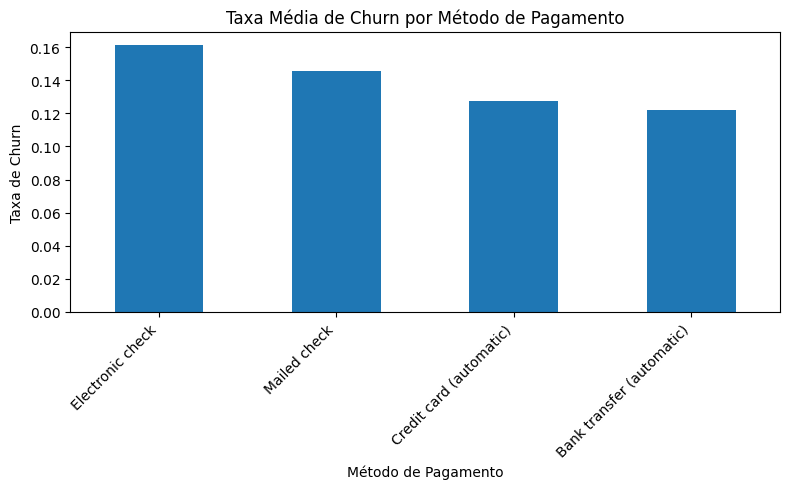

In [25]:
# cálculo da taxa média de churn
churn_by_payment = df.groupby("payment_method")["churn"].mean().sort_values(ascending=False)

# plot
plt.figure(figsize=(8,5))
churn_by_payment.plot(kind="bar")

plt.title("Taxa Média de Churn por Método de Pagamento")
plt.ylabel("Taxa de Churn")
plt.xlabel("Método de Pagamento")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()


### 📌 Insight ###

- **Electronic check = maior churn**

- **Atraso é proxy de insatisfação + risco financeiro**

# Conclusão da Fase Data Understanding #

**✅ Já sabemos que churn está fortemente ligado a:**

- **Tipo de contrato**

- **Tempo de contrato (Tenure)**

- **Reclamações**

- **Atrasos**

- **Tipo de pagamento**


# Vamos para a próxima fase... #

<a href=".\Teste 03_F3.ipynb"><strong>Fase 03 - Data Preparation</strong></a>